# Comparative Analysis of Serial vs. Single-Venture Founders
This notebook compares serial founders (those establishing multiple companies) with single-venture founders on their demographic profiles, prior career experience, and venture outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import ttest_ind, chi2_contingency

# Configure styling to match academic publication standards
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 11

In [2]:
base_dir = "../../D - Data"
matched_path = os.path.join(base_dir, "D3 - Refined Datasets for Analysis/Founder_Level_Matched_Dataset.csv")
prior_pos_path = os.path.join(base_dir, "D2 - Datasets for Matching/Founder_Prior_Position_Details.csv")

print("Loading datasets...")
cols_to_load = [
    'user_id', 'founding_event_number', 'years_since_first_job', 
    'total_prior_positions', 'max_prior_seniority',
    'has_bachelor', 'has_master', 'has_phd', 'has_stem', 'has_business', 'has_law', 'has_med', 'has_mba',
    'exp_sen_1', 'exp_sen_2', 'exp_sen_3', 'exp_sen_4', 'exp_sen_5', 'exp_sen_6', 'exp_sen_7',
    'TOTALRAISED', 'YEARFOUNDED', 'EMPLOYEES', 'REVENUE', 'Bankrupt', 'Acquired_IPO', 'DEALSIZE', 'SeriesA'
]
df_matched = pd.read_csv(matched_path, usecols=cols_to_load, low_memory=False)
df_prior = pd.read_csv(prior_pos_path, low_memory=False)

df = pd.merge(df_matched, df_prior, on=['user_id', 'founding_event_number'], how='left')
print(f"Dataset loaded. Total founding events: {len(df):,}")

Loading datasets...


Dataset loaded. Total founding events: 1,239,185


In [3]:
# Identify Serial Founders vs Single Venture Founders
user_max_events = df.groupby('user_id')['founding_event_number'].max().reset_index()
user_max_events.rename(columns={'founding_event_number': 'max_ventures'}, inplace=True)

df = pd.merge(df, user_max_events, on='user_id', how='left')
df['is_serial_founder'] = np.where(df['max_ventures'] > 1, 1, 0)

# Create user-level dataset for founder characteristics
df_founder = df.drop_duplicates(subset=['user_id']).copy()

print(f"Unique founders: {len(df_founder):,}")
print(f"Single-venture founders: {len(df_founder[df_founder['is_serial_founder'] == 0]):,} ({len(df_founder[df_founder['is_serial_founder'] == 0])/len(df_founder)*100:.2f}%)")
print(f"Serial founders: {len(df_founder[df_founder['is_serial_founder'] == 1]):,} ({len(df_founder[df_founder['is_serial_founder'] == 1])/len(df_founder)*100:.2f}%)")

Unique founders: 1,033,283
Single-venture founders: 879,598 (85.13%)
Serial founders: 153,685 (14.87%)


In [4]:
# Define outcomes
df['received_funding'] = np.where(
    (df['SeriesA'] == 1) | 
    (df['TOTALRAISED'] > 0) | 
    (df['DEALSIZE'] > 0), 1, 0
)
df['has_exit'] = np.where(df['Acquired_IPO'] == 1, 1, 0)

In [5]:
print("=== Demographic & Education Comparison (Founder Level) ===")
edu_cols = ['has_bachelor', 'has_master', 'has_phd', 'has_stem', 'has_business', 'has_law', 'has_med', 'has_mba']

summary_edu = []
for col in edu_cols:
    single_rate = df_founder[df_founder['is_serial_founder'] == 0][col].mean()
    serial_rate = df_founder[df_founder['is_serial_founder'] == 1][col].mean()
    
    contingency = pd.crosstab(df_founder['is_serial_founder'], df_founder[col])
    chi2, p_val, _, _ = chi2_contingency(contingency)
    
    summary_edu.append({
        'Education Metric': col,
        'Single-Venture Rate (%)': single_rate * 100,
        'Serial Founder Rate (%)': serial_rate * 100,
        'Difference (%)': (serial_rate - single_rate) * 100,
        'P-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

print(pd.DataFrame(summary_edu).to_string(index=False))

=== Demographic & Education Comparison (Founder Level) ===


Education Metric  Single-Venture Rate (%)  Serial Founder Rate (%)  Difference (%)       P-value Significant
    has_bachelor                75.149356                73.976497       -1.172859  9.262067e-22         Yes
      has_master                34.580588                34.668150        0.087562  5.164196e-01          No
         has_phd                 9.654255                10.135291        0.481036  9.254755e-09         Yes
        has_stem                33.613996                38.015144        4.401147 1.944885e-236         Yes
    has_business                44.485476                46.608905        2.123428  1.241576e-51         Yes
         has_law                 3.774730                 3.470479       -0.304251  1.358640e-08         Yes
         has_med                 5.445975                 4.630019       -0.815956  7.271117e-38         Yes
         has_mba                12.346716                14.510876        2.164160 2.103422e-117         Yes


In [6]:
print("=== Prior Experience Comparison (Founder Level, at First Venture) ===")
df_first = df[df['founding_event_number'] == 1].copy()

exp_cols = ['years_since_first_job', 'total_prior_positions', 'max_prior_seniority']
summary_exp = []

for col in exp_cols:
    single_val = df_first[df_first['is_serial_founder'] == 0][col].dropna()
    serial_val = df_first[df_first['is_serial_founder'] == 1][col].dropna()
    
    single_mean = single_val.mean()
    serial_mean = serial_val.mean()
    
    t_stat, p_val = ttest_ind(single_val, serial_val, equal_var=False)
    
    summary_exp.append({
        'Experience Metric': col,
        'Single-Venture Mean': single_mean,
        'Serial Founder Mean': serial_mean,
        'Difference': serial_mean - single_mean,
        'P-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

print(pd.DataFrame(summary_exp).to_string(index=False))

=== Prior Experience Comparison (Founder Level, at First Venture) ===


    Experience Metric  Single-Venture Mean  Serial Founder Mean  Difference       P-value Significant
years_since_first_job             8.844025             7.897880   -0.946145  0.000000e+00         Yes
total_prior_positions             3.769527             3.403475   -0.366052  0.000000e+00         Yes
  max_prior_seniority             3.421357             3.571676    0.150319 2.664049e-123         Yes


In [7]:
print("=== Prior Position (directly before 1st venture) Seniority Comparison ===")
sen_contingency = pd.crosstab(df_first['is_serial_founder'], df_first['prior_seniority'], normalize='index') * 100
print(sen_contingency)

sen_contingency_counts = pd.crosstab(df_first['is_serial_founder'], df_first['prior_seniority'])
chi2, p_val, _, _ = chi2_contingency(sen_contingency_counts)
print(f"\nChi-square P-value for prior seniority differences: {p_val:.4f}")

=== Prior Position (directly before 1st venture) Seniority Comparison ===
prior_seniority          1.0        2.0        3.0        4.0        5.0  \
is_serial_founder                                                          
0                  23.881291  20.913555  10.721288  12.105137  20.151266   
1                  17.280414  19.805278  10.746978  12.225250  22.846451   

prior_seniority          6.0       7.0  
is_serial_founder                       
0                   7.877997  4.349467  
1                  10.479119  6.616511  

Chi-square P-value for prior seniority differences: 0.0000


In [8]:
print("=== PitchBook Outcomes Comparison: Single-Venture vs. Serial Founders' Ventures ===")
outcome_cols = ['received_funding', 'has_exit', 'Bankrupt']
summary_outcomes = []

for col in outcome_cols:
    single_rate = df[df['is_serial_founder'] == 0][col].dropna().mean()
    serial_rate = df[df['is_serial_founder'] == 1][col].dropna().mean()
    
    contingency = pd.crosstab(df['is_serial_founder'], df[col])
    chi2, p_val, _, _ = chi2_contingency(contingency)
    
    summary_outcomes.append({
        'Outcome Metric': col,
        'Single-Venture Rate (%)': single_rate * 100,
        'Serial Founder Rate (%)': serial_rate * 100,
        'Difference (%)': (serial_rate - single_rate) * 100,
        'P-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

print(pd.DataFrame(summary_outcomes).to_string(index=False))

=== PitchBook Outcomes Comparison: Single-Venture vs. Serial Founders' Ventures ===


  Outcome Metric  Single-Venture Rate (%)  Serial Founder Rate (%)  Difference (%)  P-value Significant
received_funding                 2.977497                 5.916788        2.939291 0.000000         Yes
        has_exit                 1.544683                 3.091880        1.547197 0.000000         Yes
        Bankrupt                21.393256                22.189204        0.795949 0.019103         Yes


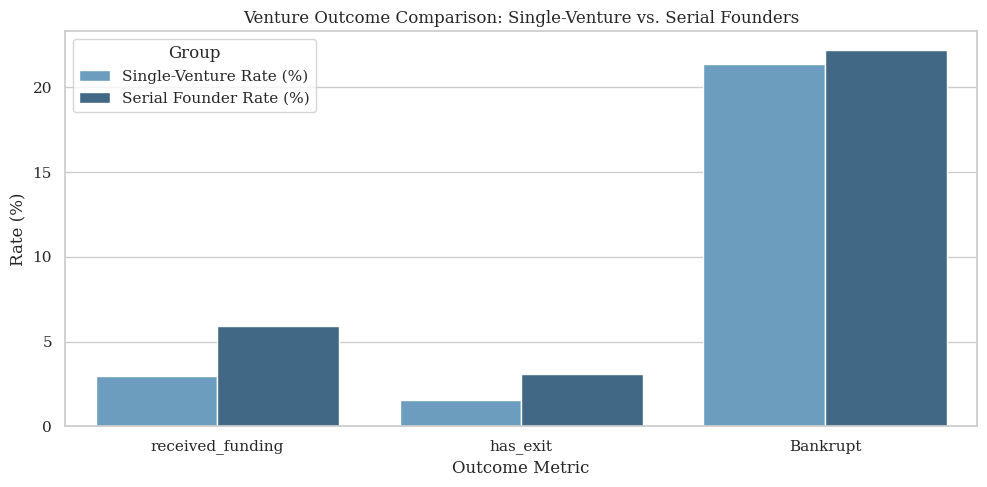

In [9]:
# Plot outcome differences
outcome_rates = pd.DataFrame(summary_outcomes)
outcome_melted = pd.melt(
    outcome_rates, 
    id_vars=['Outcome Metric'], 
    value_vars=['Single-Venture Rate (%)', 'Serial Founder Rate (%)'],
    var_name='Group', 
    value_name='Rate (%)'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=outcome_melted, x='Outcome Metric', y='Rate (%)', hue='Group', palette='Blues_d')
plt.title("Venture Outcome Comparison: Single-Venture vs. Serial Founders")
plt.ylabel("Rate (%)")
plt.tight_layout()
plt.show()

In [10]:
print("=== Serial Founder Ventures: First Venture vs. Subsequent Ventures ===")
df_serial = df[df['is_serial_founder'] == 1].copy()
df_serial['venture_type'] = np.where(df_serial['founding_event_number'] == 1, 'First Venture', 'Subsequent Venture')

summary_serial_comparison = []
for col in outcome_cols:
    first_rate = df_serial[df_serial['venture_type'] == 'First Venture'][col].mean()
    subseq_rate = df_serial[df_serial['venture_type'] == 'Subsequent Venture'][col].mean()
    
    contingency = pd.crosstab(df_serial['venture_type'], df_serial[col])
    chi2, p_val, _, _ = chi2_contingency(contingency)
    
    summary_serial_comparison.append({
        'Outcome Metric': col,
        'First Venture Rate (%)': first_rate * 100,
        'Subsequent Venture Rate (%)': subseq_rate * 100,
        'Difference (%)': (subseq_rate - first_rate) * 100,
        'P-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

print(pd.DataFrame(summary_serial_comparison).to_string(index=False))

=== Serial Founder Ventures: First Venture vs. Subsequent Ventures ===


  Outcome Metric  First Venture Rate (%)  Subsequent Venture Rate (%)  Difference (%)       P-value Significant
received_funding                4.552819                     6.934853        2.382033 5.496113e-197         Yes
        has_exit                2.704883                     3.380735        0.675851  5.660534e-31         Yes
        Bankrupt               22.574501                    21.994450       -0.580051  2.894751e-01          No


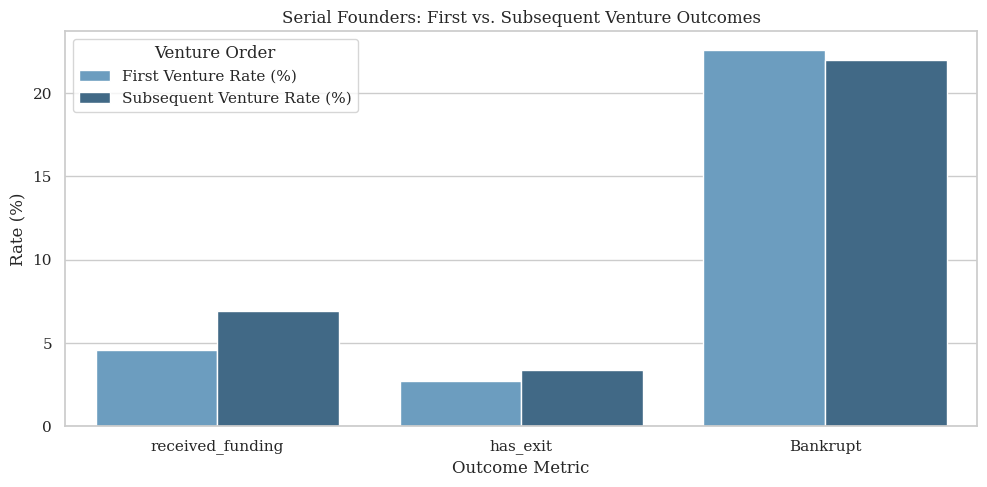

In [11]:
# Plot first vs subsequent ventures for serial founders
serial_rates = pd.DataFrame(summary_serial_comparison)
serial_melted = pd.melt(
    serial_rates, 
    id_vars=['Outcome Metric'], 
    value_vars=['First Venture Rate (%)', 'Subsequent Venture Rate (%)'],
    var_name='Venture Order', 
    value_name='Rate (%)'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=serial_melted, x='Outcome Metric', y='Rate (%)', hue='Venture Order', palette='Blues_d')
plt.title("Serial Founders: First vs. Subsequent Venture Outcomes")
plt.ylabel("Rate (%)")
plt.tight_layout()
plt.show()